# HELIX Revenue Prediction

## Notebook 02 — Univariate Analysis

Author : Hilmi Aji

Objective

Understand the distribution of each feature individually before performing feature engineering and model development.

In [18]:
# import library
from pathlib import Path

from IPython.display import display
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

In [19]:
# load dataset
PROJECT_ROOT = Path("..")

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "ecommerce_customer_behavior_dataset_v2.csv"

df = pd.read_csv(DATA_PATH)

df["Date"] = pd.to_datetime(df["Date"])

In [20]:
# data preparation
target = "Total_Amount"

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

categorical_cols = df.select_dtypes(include="object").columns.tolist()

boolean_cols = df.select_dtypes(include="bool").columns.tolist()

print("Numeric :", len(numeric_cols))
print("Categorical :", len(categorical_cols))
print("Boolean :", len(boolean_cols))

Numeric : 9
Categorical : 7
Boolean : 1


In [21]:
# numerical feature
summary = df[numeric_cols].describe().T

summary["Missing"] = df[numeric_cols].isna().sum()

summary["Skewness"] = df[numeric_cols].skew()

summary["Kurtosis"] = df[numeric_cols].kurt()

display(summary)

,count,mean,std,min,25%,50%,75%,max,Missing,Skewness,Kurtosis
Age,17049.0,34.945745,11.046855,18.00,26.00,35.00,42.00,75.00,0,0.320455,-0.401339
Unit_Price,17049.0,447.901689,722.319705,5.05,73.26,174.68,494.57,7900.01,0,3.645695,17.603905
Quantity,17049.0,3.011379,1.417027,1.00,2.00,3.00,4.00,5.00,0,-0.011929,-1.303566
Discount_Amount,17049.0,69.788135,240.704662,0.00,0.00,0.00,32.71,6538.29,0,8.640295,120.075599
Total_Amount,17049.0,1277.438711,2358.436375,6.21,172.97,455.85,1267.75,37852.05,0,4.584842,30.380083
Session_Duration_Minutes,17049.0,14.535633,2.925524,4.00,13.00,15.00,17.00,26.00,0,-0.008454,0.038253
Pages_Viewed,17049.0,9.003109,2.259954,1.00,7.00,9.00,11.00,18.00,0,-0.033469,-0.012778
Delivery_Time_Days,17049.0,6.503607,3.488787,1.00,4.00,6.00,8.00,25.00,0,1.132570,1.874366
Customer_Rating,17049.0,3.899408,1.128803,1.00,3.00,4.00,5.00,5.00,0,-0.930286,0.088604


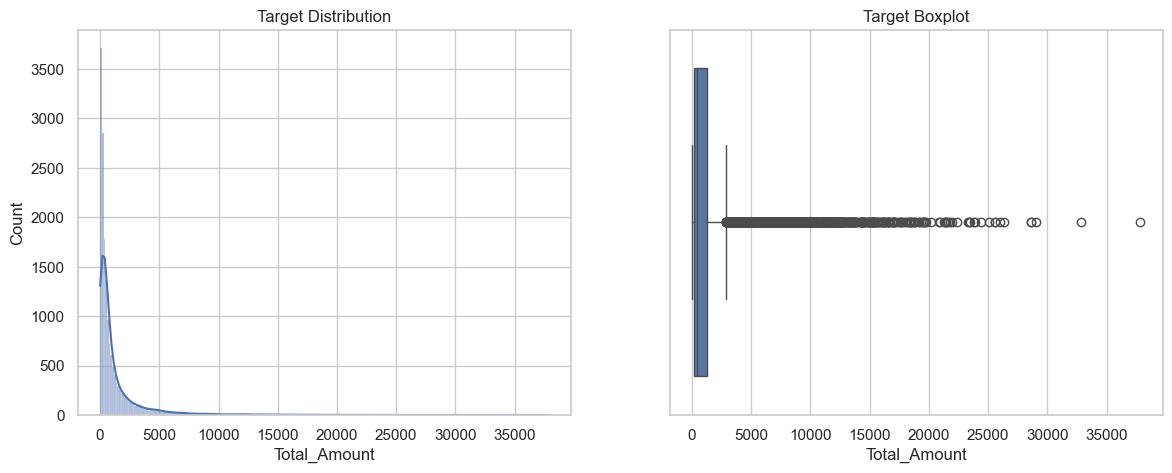

count    17049.000000
mean      1277.438711
std       2358.436375
min          6.210000
25%        172.970000
50%        455.850000
75%       1267.750000
max      37852.050000
Name: Total_Amount, dtype: float64

Skewness : 4.584841564259209
Kurtosis : 30.380082777089246


In [22]:
# target variable analysis
target = "Total_Amount"

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df[target], kde=True, ax=ax[0])

ax[0].set_title("Target Distribution")

sns.boxplot(x=df[target], ax=ax[1])

ax[1].set_title("Target Boxplot")

plt.show()

print(df[target].describe())

print()

print("Skewness :", df[target].skew())

print("Kurtosis :", df[target].kurt())

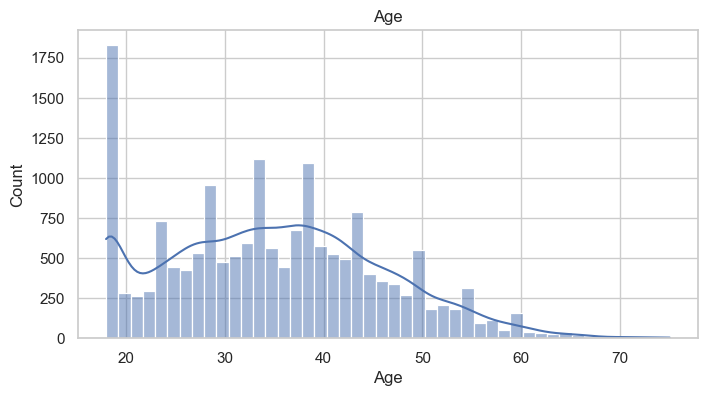

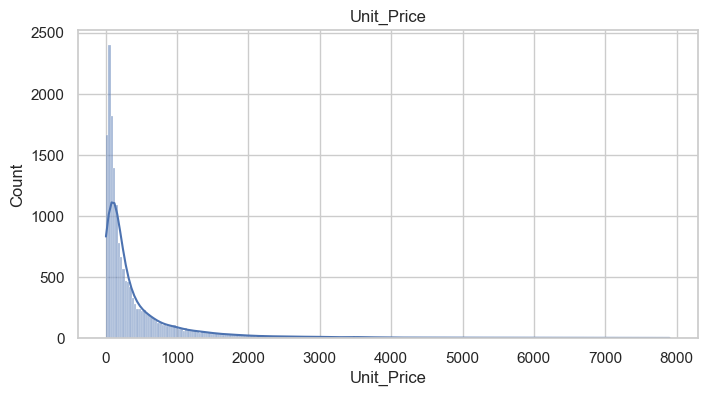

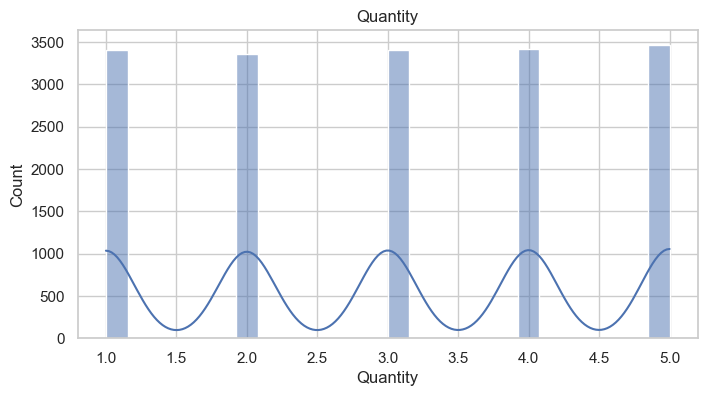

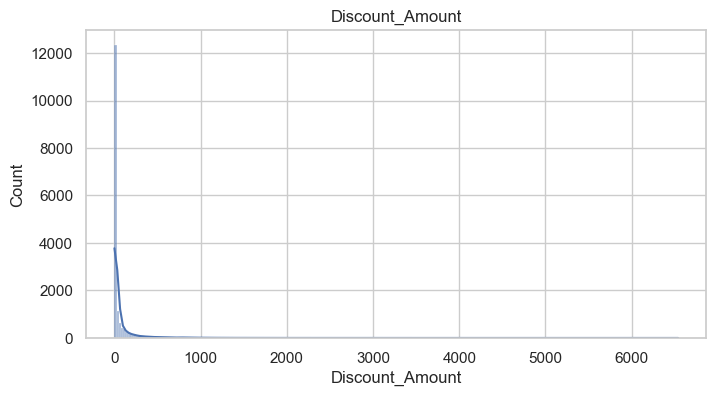

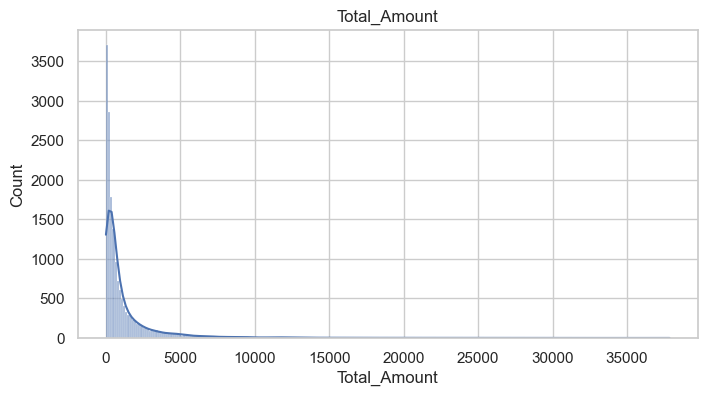

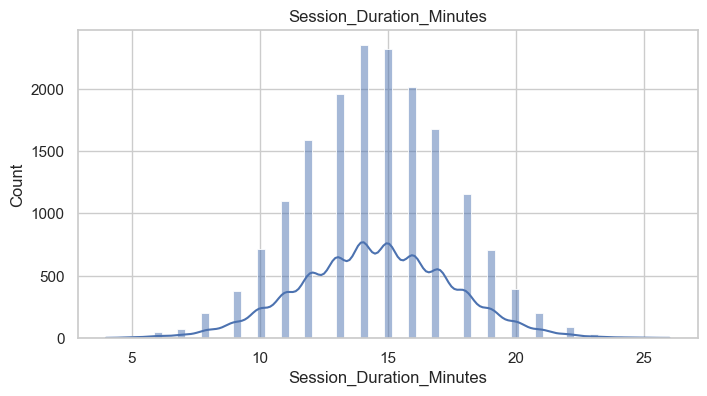

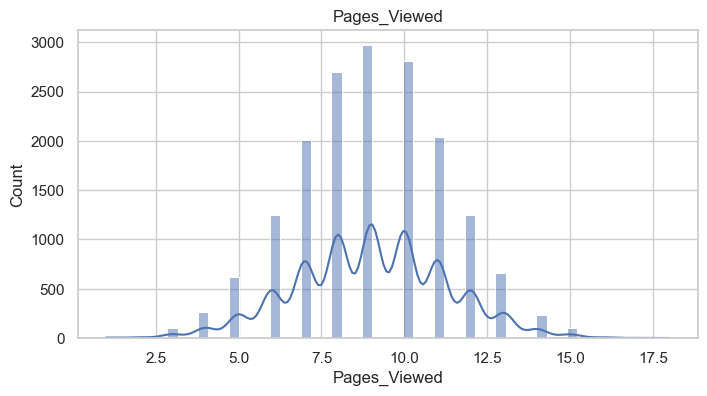

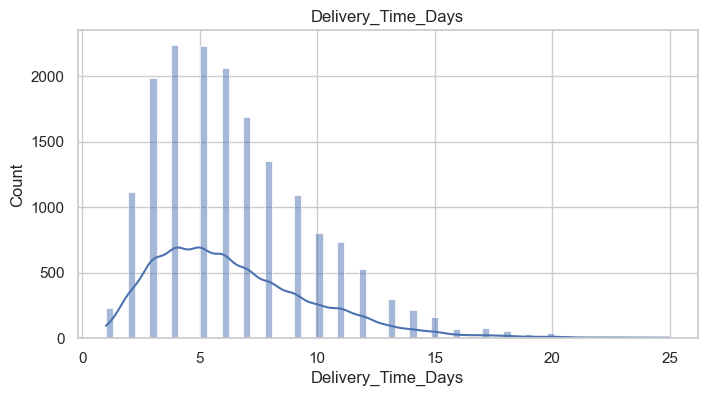

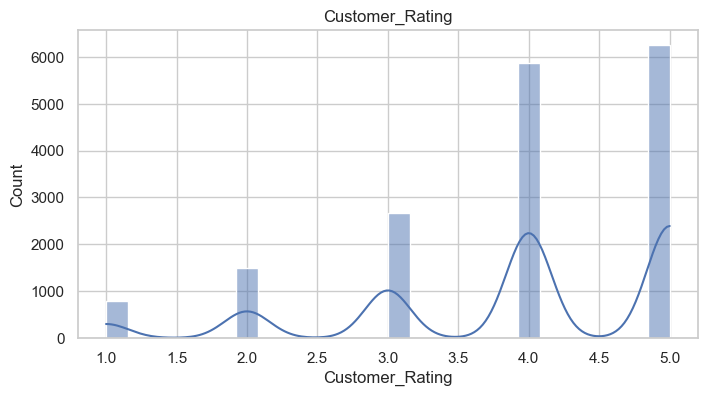

In [23]:
# numerical distribution
for col in numeric_cols:
    plt.figure(figsize=(8, 4))

    sns.histplot(df[col], kde=True)

    plt.title(col)

    plt.show()

In [24]:
# statistical summary
stats = pd.DataFrame(
    {
        "Mean": df[numeric_cols].mean(),
        "Median": df[numeric_cols].median(),
        "Std": df[numeric_cols].std(),
        "Min": df[numeric_cols].min(),
        "Max": df[numeric_cols].max(),
    }
)

display(stats)

,Mean,Median,Std,Min,Max
Age,34.945745,35.00,11.046855,18.00,75.00
Unit_Price,447.901689,174.68,722.319705,5.05,7900.01
Quantity,3.011379,3.00,1.417027,1.00,5.00
Discount_Amount,69.788135,0.00,240.704662,0.00,6538.29
Total_Amount,1277.438711,455.85,2358.436375,6.21,37852.05
Session_Duration_Minutes,14.535633,15.00,2.925524,4.00,26.00
Pages_Viewed,9.003109,9.00,2.259954,1.00,18.00
Delivery_Time_Days,6.503607,6.00,3.488787,1.00,25.00
Customer_Rating,3.899408,4.00,1.128803,1.00,5.00


,Skewness,Category
Discount_Amount,8.640295,Highly Skewed
Total_Amount,4.584842,Highly Skewed
Unit_Price,3.645695,Highly Skewed
Delivery_Time_Days,1.132570,Highly Skewed
Age,0.320455,Approximately Symmetric
Session_Duration_Minutes,-0.008454,Approximately Symmetric
Quantity,-0.011929,Approximately Symmetric
Pages_Viewed,-0.033469,Approximately Symmetric
Customer_Rating,-0.930286,Moderately Skewed


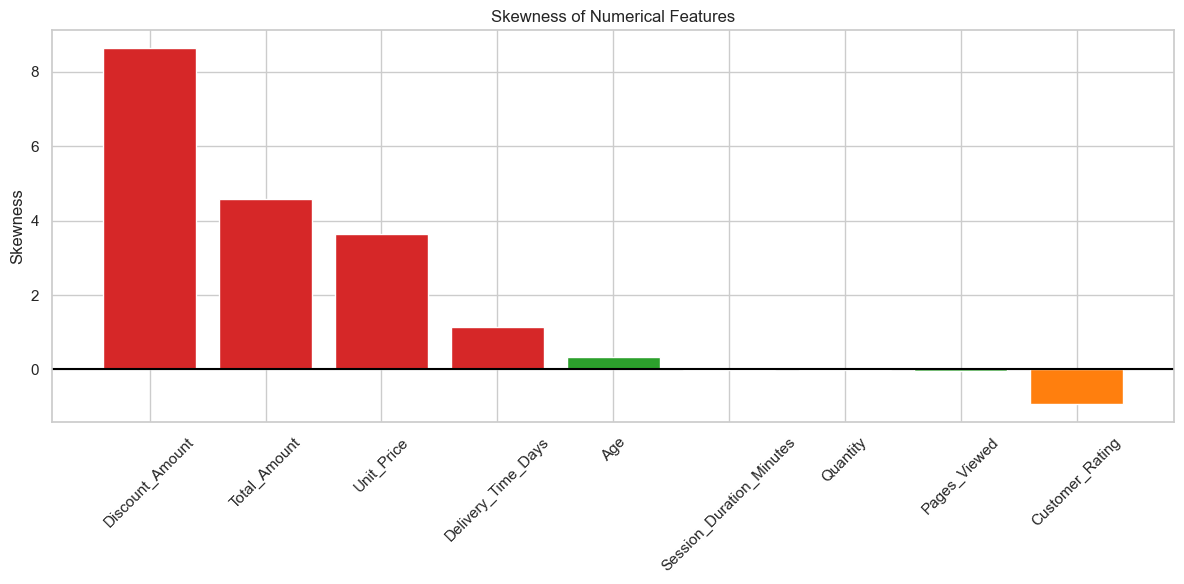

In [13]:
# skewness
skewness = (
    df[numeric_cols].skew().sort_values(ascending=False).to_frame(name="Skewness")
)


def skew_category(value):
    """
    Categorize skewness value.
    """
    if abs(value) < 0.5:
        return "Approximately Symmetric"

    elif abs(value) < 1:
        return "Moderately Skewed"

    return "Highly Skewed"


skewness["Category"] = skewness["Skewness"].apply(skew_category)

display(skewness)

plt.figure(figsize=(12, 6))

colors = [
    "tab:red" if abs(v) >= 1 else "tab:orange" if abs(v) >= 0.5 else "tab:green"
    for v in skewness["Skewness"]
]

plt.bar(skewness.index, skewness["Skewness"], color=colors)

plt.axhline(0, color="black")

plt.xticks(rotation=45)

plt.ylabel("Skewness")

plt.title("Skewness of Numerical Features")

plt.tight_layout()

plt.show()

,Kurtosis,Category
Discount_Amount,120.075599,Heavy Tail
Total_Amount,30.380083,Heavy Tail
Unit_Price,17.603905,Heavy Tail
Delivery_Time_Days,1.874366,Normal Tail
Customer_Rating,0.088604,Normal Tail
Session_Duration_Minutes,0.038253,Normal Tail
Pages_Viewed,-0.012778,Light Tail
Age,-0.401339,Light Tail
Quantity,-1.303566,Light Tail


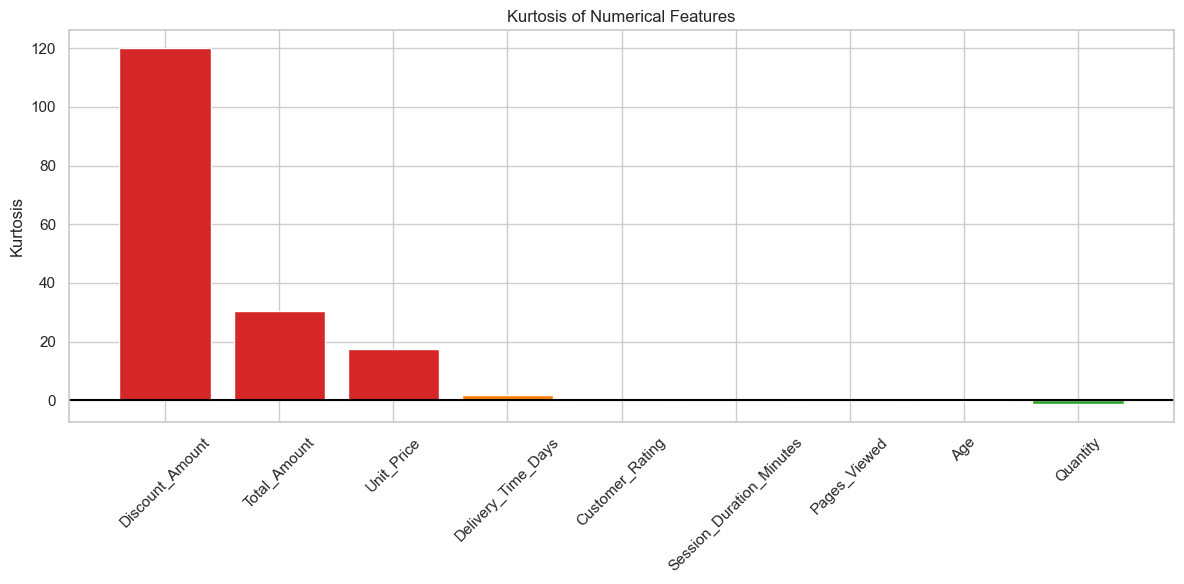

In [25]:
# kurtosis analysis
kurtosis = (
    df[numeric_cols].kurt().sort_values(ascending=False).to_frame(name="Kurtosis")
)


def kurtosis_category(value):
    """
    Categorize kurtosis.
    """

    if value > 3:
        return "Heavy Tail"

    elif value < 0:
        return "Light Tail"

    return "Normal Tail"


kurtosis["Category"] = kurtosis["Kurtosis"].apply(kurtosis_category)

display(kurtosis)

plt.figure(figsize=(12, 6))

colors = []

for value in kurtosis["Kurtosis"]:
    if value > 3:
        colors.append("tab:red")

    elif value < 0:
        colors.append("tab:green")

    else:
        colors.append("tab:orange")

plt.bar(kurtosis.index, kurtosis["Kurtosis"], color=colors)

plt.axhline(0, color="black")

plt.xticks(rotation=45)

plt.ylabel("Kurtosis")

plt.title("Kurtosis of Numerical Features")

plt.tight_layout()

plt.show()

In [26]:
# outlier analysis
outlier_report = []

for col in numeric_cols:
    q1 = df[col].quantile(0.25)

    q3 = df[col].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr

    upper = q3 + 1.5 * iqr

    outlier = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_report.append({"Feature": col, "Outlier": outlier})

outlier_report = pd.DataFrame(outlier_report)

display(outlier_report)

,Feature,Outlier
0,Age,50
1,Unit_Price,1757
2,Quantity,0
3,Discount_Amount,2789
4,Total_Amount,1943
5,Session_Duration_Minutes,85
6,Pages_Viewed,1
7,Delivery_Time_Days,475
8,Customer_Rating,0


In [27]:
# boolean feature
for col in boolean_cols:
    display(df[col].value_counts())

Is_Returning_Customer
True     15039
False     2010
Name: count, dtype: int64

## Numerical Features

- Check skewed variables.
- Consider log transformation for highly skewed variables.
- RobustScaler may be preferred due to outliers.

---

## Categorical Features

- Frequency Encoding for high-cardinality variables.
- One-Hot Encoding for low-cardinality variables.

---

## Target

Total_Amount is heavily right-skewed.

Transformation will be evaluated during Feature Engineering.

---

## Outlier

Outliers should not be removed immediately because they may represent genuine high-value transactions.

## Interpretation

### Skewness

- Features with **|Skewness| < 0.5** are considered approximately symmetric.
- Features with **0.5 ≤ |Skewness| < 1** are moderately skewed.
- Features with **|Skewness| ≥ 1** are highly skewed and may require transformation (e.g., logarithmic transformation).

### Kurtosis

- **Kurtosis > 3** indicates a heavy-tailed distribution and suggests the presence of extreme values or outliers.
- **0 ≤ Kurtosis ≤ 3** indicates a distribution close to normal.
- **Kurtosis < 0** indicates a light-tailed distribution with fewer extreme observations.

The results from both analyses will guide preprocessing decisions, including feature transformation, scaling methods, and outlier handling in the next stages of the project.

### Key Findings

- Target is highly skewed.
- Several numerical variables contain outliers.
- Categorical variables are well balanced.
- Dataset quality is excellent.
- No preprocessing is required for missing values.
- Leakage investigation will continue in Notebook 05.